# Seaborn

## Introduction

Check the [Seaborn documentation](https://seaborn.pydata.org/) for more information.

Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures.

Seaborn closely integrates with Matplotlib and works anywhere Matplotlib is supported. This includes interactive data exploration in Jupyter, real-time plotting in graphical apps, and saving figures in raster or vector formats for reports or publications.

Seaborn makes it easy to create visualizations quickly with high-level functions. For advanced or custom plots, understanding Matplotlib’s basics and API is often needed.

## Installation

Seaborn can be installed from [PyPI](https://pypi.org/project/seaborn/)

```bash
pip install seaborn
```

## Importing Seaborn

Typically, Seaborn is imported using the alias sns. We will also import Pandas and Matplotlib, as they are commonly used alongside Seaborn.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Optionally, you can set the theme of your plots.

In [2]:
sns.set_theme(style="darkgrid")

## Loading the Data

Seaborn works best with Pandas DataFrames. For this demonstration, we will use three datasets:

- The classic [**Iris Dataset**](https://archive.ics.uci.edu/ml/datasets/iris) introduced in R. A. Fisher’s paper, *The Use of Multiple Measurements in Taxonomic Problems (1936)*. It contains measurements from three species of iris flowers, with 50 samples per species.

- The [**Dow Jones Dataset**](https://fred.stlouisfed.org/series/M1109BUSM293NNBR) which shows the monthly US stock market index values from 1915 to 1968. It is a time-series dataset showing trends in financial market performance over time.

- The [**Tips Dataset**](https://rdrr.io/cran/reshape2/man/tips.html) that shows data about tips recieved by a waiter over a couple of months.

These datasets are available as example datasets in Seaborn, allowing them to be loaded directly.

**Note:** Check [here](https://github.com/mwaskom/seaborn-data/) for more of Seaborn's example datasets.

In [3]:
iris = sns.load_dataset("iris")

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [5]:
dowjones = sns.load_dataset("dowjones")

dowjones.head()

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45


In [6]:
dowjones.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    649 non-null    datetime64[us]
 1   Price   649 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 10.3 KB


In [7]:
tips = sns.load_dataset("tips")

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [8]:
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


## Relational Plots

Statistical analysis is a process of understanding how variables in a dataset relate to each other and how those relationships depend on other variables. Visualization plays a crucial role in this process because the human eye is highly adept at detecting patterns, trends, and structures when data is presented clearly. 

This is why relational plots in Seaborn are used to explore relationships between variables in a dataset. 

Although relational plots are typically two-dimensional (x and y), they can represent additional variables using visual encodings such as `hue`, `size`, and `style`.

### `scatterplot`

A scatterplot shows the relationship between two continuous variables by plotting individual data points. Each point represents one observation in the dataset. It is used to identify patterns such as correlations, clusters, and outliers in the data.

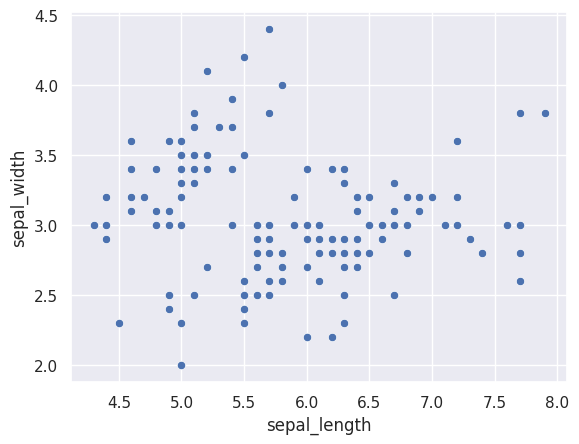

In [9]:
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width")
plt.show()

Just like in Matplotlib, you can style and customize plots.

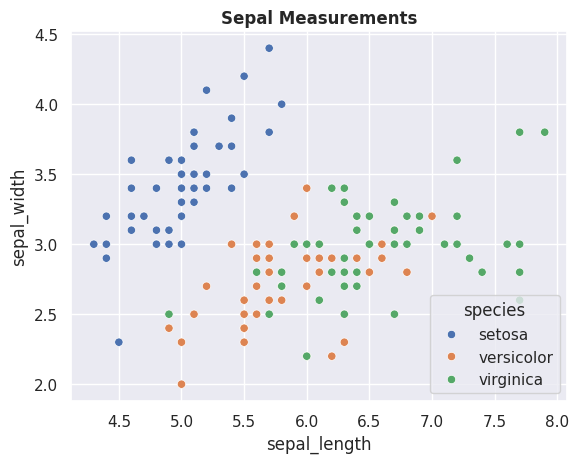

In [10]:
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", hue="species")
plt.title("Sepal Measurements", fontweight="bold")
plt.show()

### `lineplot`

A lineplot shows the relationship between variables where one variable has a natural order (like time). It connects data points with a line to show change over progression.

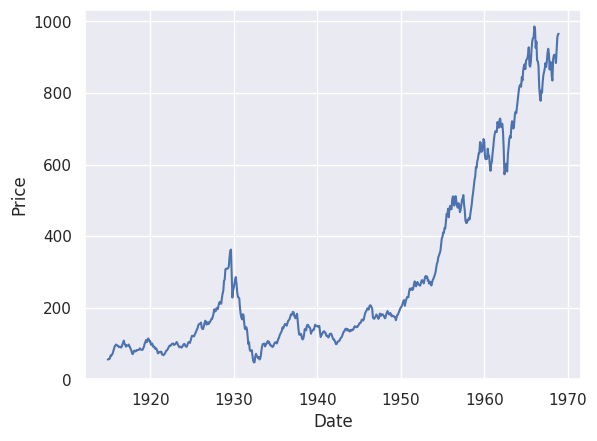

In [11]:
sns.lineplot(data=dowjones, x="Date", y="Price")
plt.show()

## Categorical Plots

We have seen how different visual representations can be used to explore relationships between multiple variables in a dataset. In the previous examples, we focused mainly on cases where the primary relationship is between two numerical variables.

However, if one of the main variables is **categorical** (divided into discrete groups) it may be helpful to use a more specialized approach to visualization.

### `barplot`

A barplot is used to show the relationship between a categorical variable and a numerical variable by displaying an aggregated value, usually the mean, for each category. By default, it also includes error bars, which show the uncertainty or variability in the estimate, typically using confidence intervals.

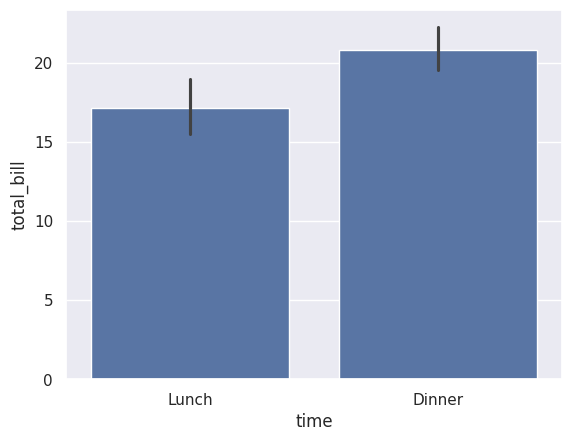

In [12]:
sns.barplot(data=tips, x="time", y="total_bill")
plt.show()

Multiple groups within categorical plots are handled using the `hue` parameter. The `hue` parameter introduces a second categorical grouping. So in barplots, instead of having just one bar per category on the x-axis, Seaborn splits each category into sub-groups and draws a separate bar for each one.

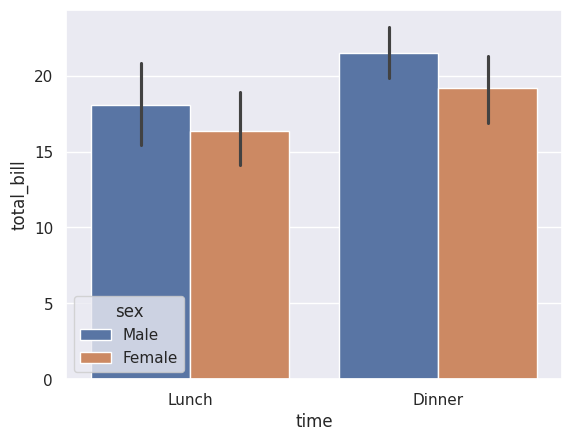

In [13]:
sns.barplot(data=tips, x="time", y="total_bill", hue="sex")
plt.show()

### `countplot`

A countplot is a categorical estimate plot that shows the number of observations in each category of a variable. It works by automatically counting how many times each category appears in the dataset and displaying these counts as bars. This makes it useful for quickly understanding the distribution of categorical data, such as checking how many samples belong to each class in a dataset.

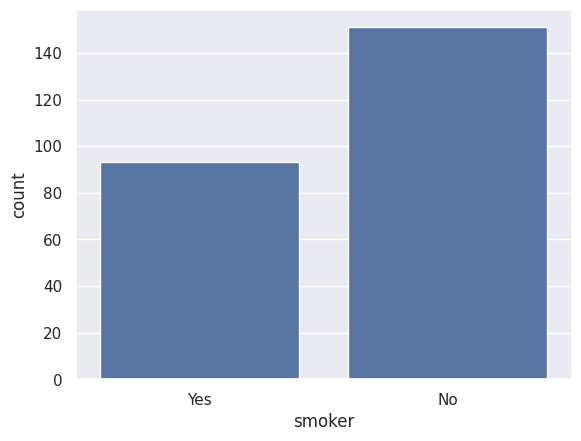

In [14]:
sns.countplot(data=tips, x="smoker")
plt.show()

The `hue` parameter can also be used here to add a second cateorical grouping.

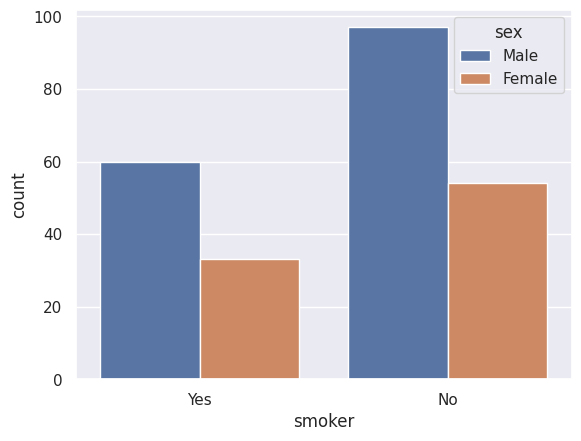

In [15]:
sns.countplot(data=tips, x="smoker", hue="sex")
plt.show()

### `boxplot`

In descriptive statistics, a box plot is a method for demonstrating graphically the locality, spread and skewness groups of numerical data through their quartiles. It is based on five key summary values: the minimum, first quartile (Q1), median, third quartile (Q3), and maximum.

A box plot divides also the data into four equal parts, with each section containing approximately 25% of the observations.

<p align="center">
    <img src="./images/boxplotfig01.jpg" alt="Image describing the boxplot Source: simplypsychology.org", width=720>
</p>

#### Key Components of a Box Plot

- **Interquartile Range (IQR):** The box represents the middle 50% of the data, ranging from the 25th percentile (Q1) to the 75th percentile (Q3).

- **Median:** The line inside the box shows the median (Q2), which splits the data into two equal halves.

- **Whiskers:** The lines extending from the box show the range of the remaining data, excluding outliers.

- **Minimum and Maximum (non-outliers):** The ends of the whiskers represent the smallest and largest values within the normal range of the data.

- **Outliers:** Individual points outside the whiskers represent extreme values that differ significantly from the rest of the dataset.

<p align="center">
    <img src="./images/boxplotfig02.jpg" alt="A box plot showing the hours slept for each day of the week, for a group of 20 high school students. Source: heelpbook.net" width=720>
    <br>
</p>

The image above shows a box plot representing the number of hours slept each day of the week for a group of 20 high school students. See if you can interpret the plot.

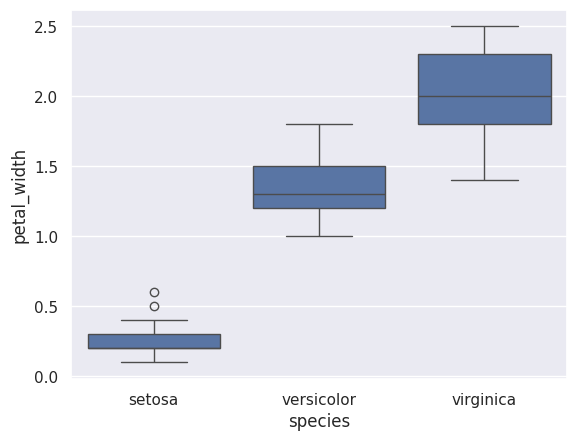

In [16]:
sns.boxplot(data=iris, x="species", y="petal_width")
plt.show()

## Distribution Plots

Distribution plots are used to understand how your data is spread and what patterns it contains before analyzing or modeling data. They are used to answer questions like:

- What range do the observations cover? 
- What is their central tendency? 
- Are they heavily skewed in one direction? 
- Is there evidence for bimodality? 
- Are there significant outliers? 
- Do the answers to these questions vary across subsets defined by other variables?

### `histplot`

A histogram works by dividing the range of a numeric variable into a set of intervals called **bins**, then counting how many observations fall into each bin. These counts are displayed as bars, where the height of each bar represents the number of data points within that interval.

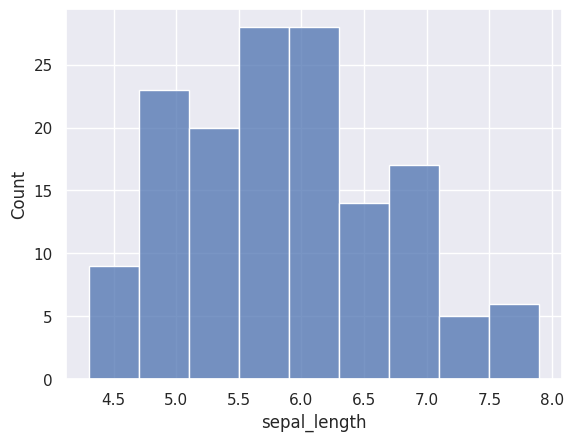

In [17]:
sns.histplot(data=iris, x="sepal_length")
plt.show()

Choosing the size of the bins is important because it affects how the distribution is interpreted. If the bins are too large, the histogram becomes overly simplified and can hide important patterns in the data. If the bins are too small, the histogram becomes too detailed and noisy, making it harder to see the overall shape of the distribution.

In Seaborn, you can control this using `bins` or `binwidth`. The `bins` parameter lets you directly set how many bars the histogram will have, while `binwidth` lets you define the size of each bin instead.

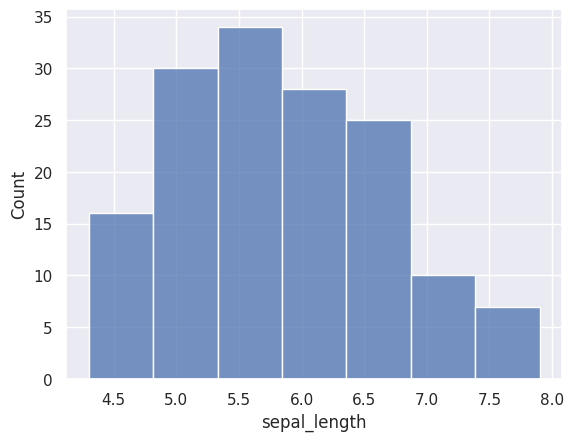

In [18]:
sns.histplot(data=iris, x="sepal_length", bins=7)
plt.show()

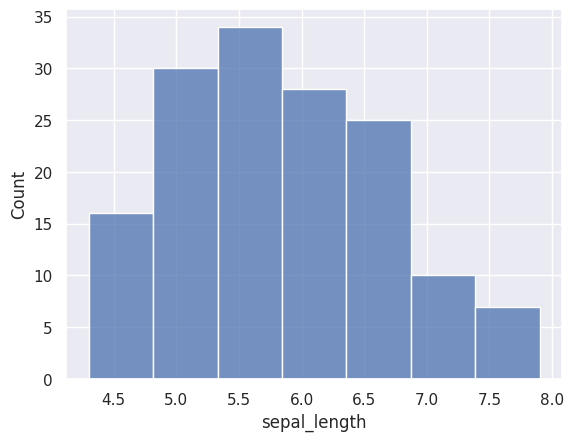

In [19]:
sns.histplot(data=iris, x="sepal_length", binwidth=0.5)
plt.show()

You can also visualize different categories

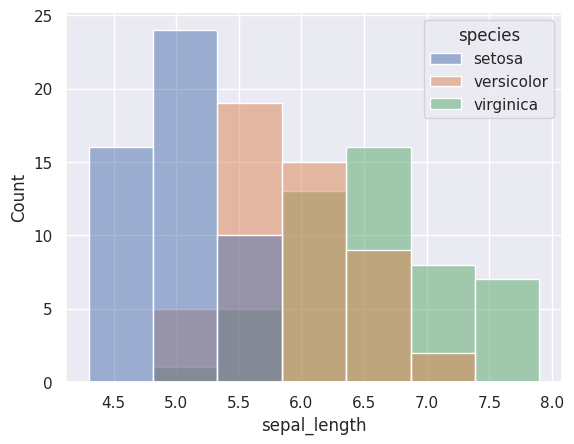

In [20]:
sns.histplot(data=iris, x="sepal_length", binwidth=0.5, hue="species", multiple="layer")
plt.show()

Sometimes, you may choose to plot a Kernel Density Estimate (KDE) curve on top of a histogram by setting `kde=True`.

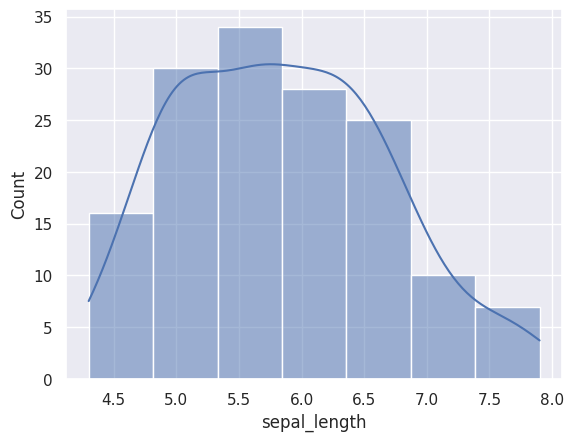

In [21]:
sns.histplot(data=iris, x="sepal_length", binwidth=0.5, kde=True)
plt.show()

### `kdeplot`

A **KDE (Kernel Density Estimate)** is a way to estimate the probability distribution of a dataset as a smooth curve instead of using bars like a histogram.

Instead of grouping values into bins, KDE places a small smooth curve (called a kernel) on each data point. These small curves are then added together to form one continuous line that represents the overall shape of the data. The result is a smooth approximation of how the data is distributed.

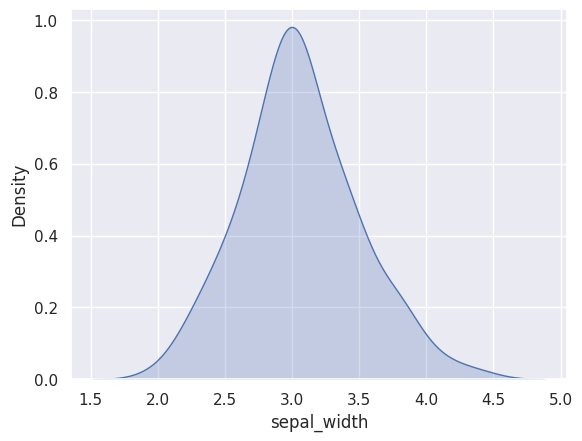

In [22]:
sns.kdeplot(data=iris, x="sepal_width", fill=True)
plt.show()

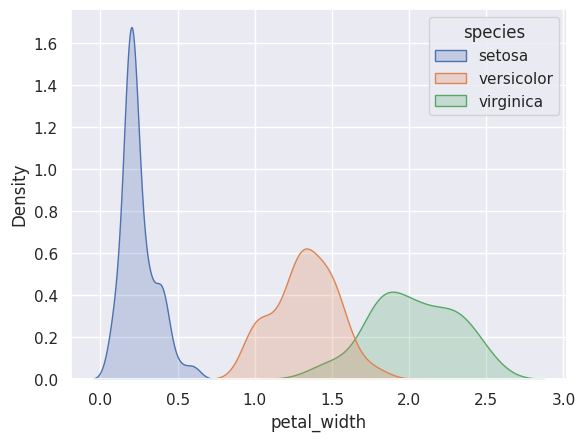

In [23]:
sns.kdeplot(data=iris, x="petal_width", fill=True, hue="species", multiple="layer")
plt.show()

Again, you can visualize categories.

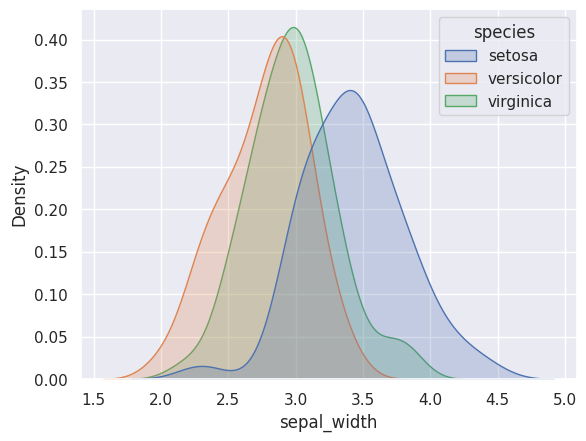

In [24]:
sns.kdeplot(data=iris, x="sepal_width", hue="species", fill=True, multiple="layer")
plt.show()

## Multi-plot Grids

### `pairplot`

A pairplot creates a grid of plots where each numeric variable is paired with every other numeric variable. On the diagonal, it usually shows the distribution of each variable (often as a histogram or KDE plot), while the off-diagonal plots show scatterplots that reveal how two variables relate to each other.

**Note:** This can take a long time to run, especially with large datasets or many variables.

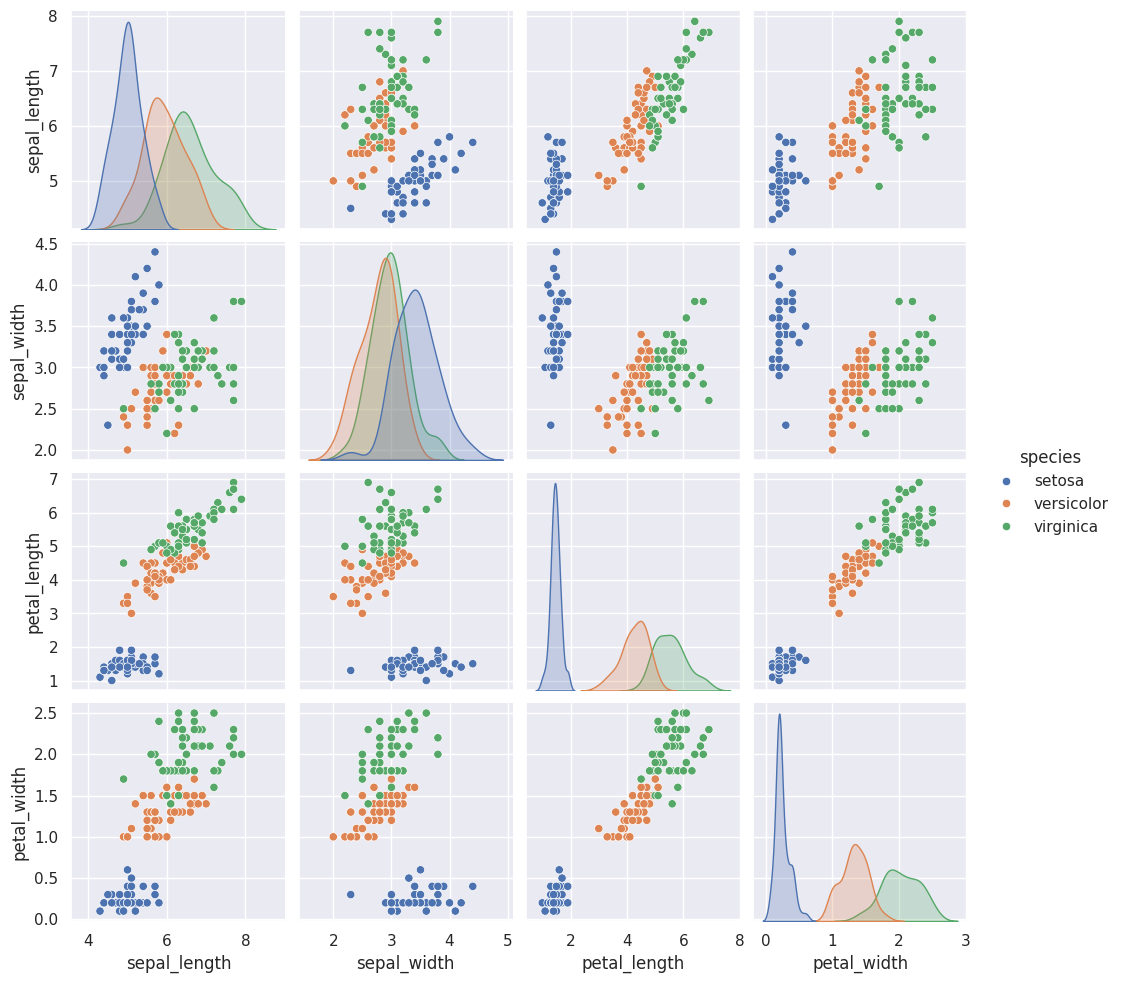

In [25]:
sns.pairplot(data=iris, hue="species")
plt.show()